In [1]:
from utils import *
from imports import *
from pipelines import run_testing_pipeline
from configs import load_config
from dataloaders import get_dataloader, collate

Load config and setup

In [2]:
config = load_config(path="../configs/default.yaml")
checkpoint_dir = "../runs/20260222-130917"     # The best run

print(f"Testing model from: {checkpoint_dir}")

Testing model from: ../runs/20260222-130917


Load saved test split

In [3]:
gt_test, noisy_test = load_data_split(config=config)

print(f"Loaded data split:")
print(f"    Test set: {len(gt_test)} images")

Loaded data split:
    Test set: 846 images


Create test dataloader

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_loader = get_dataloader(
    config=config,
    gt_img_names=gt_test,
    noisy_img_names=noisy_test,
    device=device,
    batch_size=config.test.batch_size,
    collate_fn=collate,
    shuffle=False,
    augment=False
)

print(f" Created test loader: {len(test_loader.dataset)} images")

 Created test loader: 846 images


Run testing

In [5]:
test_pipeline = run_testing_pipeline(
    config=config,
    test_loader=test_loader,
    checkpoint_dir=checkpoint_dir,
)


Using device: cuda

LOADING CHECKPOINT
Total parameters: 7,766,051
Model size: ~29.63 MB (float32)
 Loaded model from ..\runs\20260222-130917\best_model.pth
    Epoch: 20
    Val Loss: 0.0006
    This was the best model
Loaded model from ..\runs\20260222-130917\best_model.pth

TESTING

Running inference on test set...


Testing: 100%|██████████| 53/53 [03:05<00:00,  3.51s/it]



TESTING COMPLETE

TEST RESULTS
Number of test images: 846

Average Metrics:
    PSNR: 33.95 dB
    SSIM: 0.8538

Quality Rating: Very Good

PSNR Statistics:
    Min:        23.08 dB
    Max:        40.17 dB
    Median:    34.61 dB
    Std:        3.33 dB

SSIM Statistics:
    Min:        0.4480
    Max:        0.9741
    Median:    0.8893
    Std:        0.1030

SAVING RESULTS & VISUALISATIONS
Saved test results to ..\runs\20260222-130917\test_results.json
Test results saved
Loaded training history from ..\runs\20260222-130917\training_history.json
Saved summary to ..\runs\20260222-130917\summary.txt
Summary saved
Saving visualisations...
Saved training metrics to ..\runs\20260222-130917\figures\training_metrics.png
Saved test distribution to ..\runs\20260222-130917\figures\test_results_distribution.png
Saved PSNR vs SSIM scatter plot to ..\runs\20260222-130917\figures\psnr_vs_ssim.png
Loading only 6 images (out of 846)...
Saved best/worst results to ..\runs\20260222-130917\figures\be

Quick summary

In [6]:
test_pipeline.get_summary()


TESTING SUMMARY

Test Results:
    Images tested: 846
    Avg PSNR: 33.95 dB
    Avg SSIM: 0.8538 

Results saved to: ..\runs\20260222-130917


Visualise results distribution

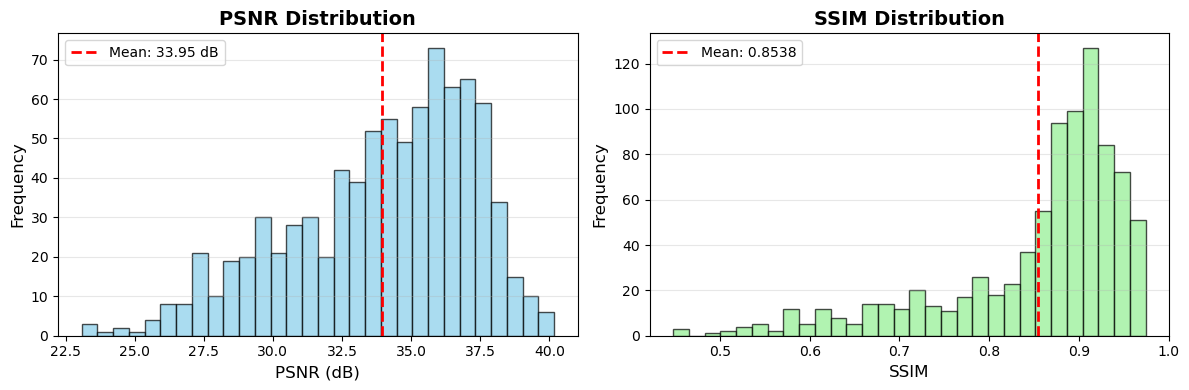

In [7]:
plot_test_results_distribution(results=test_pipeline.test_results)


PSNR vs SSIM correlation

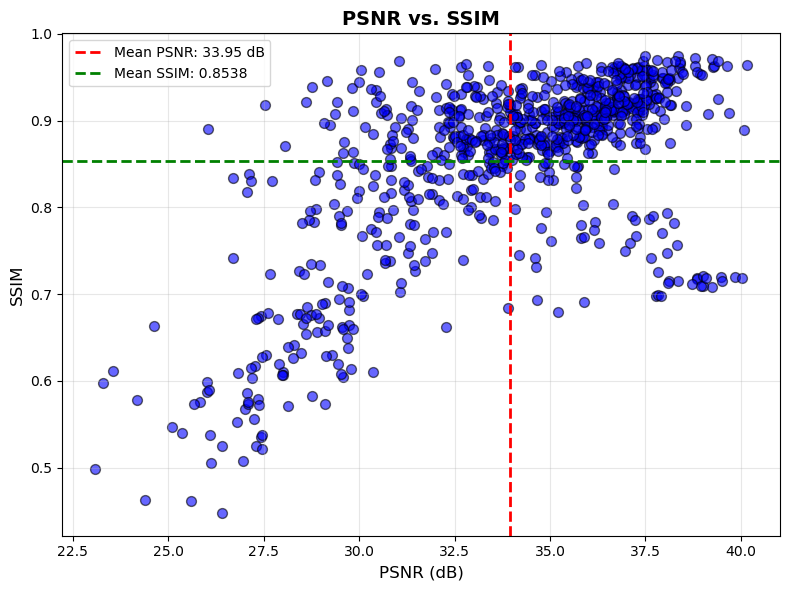

In [8]:
plot_metric_vs_metric(results=test_pipeline.test_results)

Best and worst examples

Loading only 6 images (out of 846)...


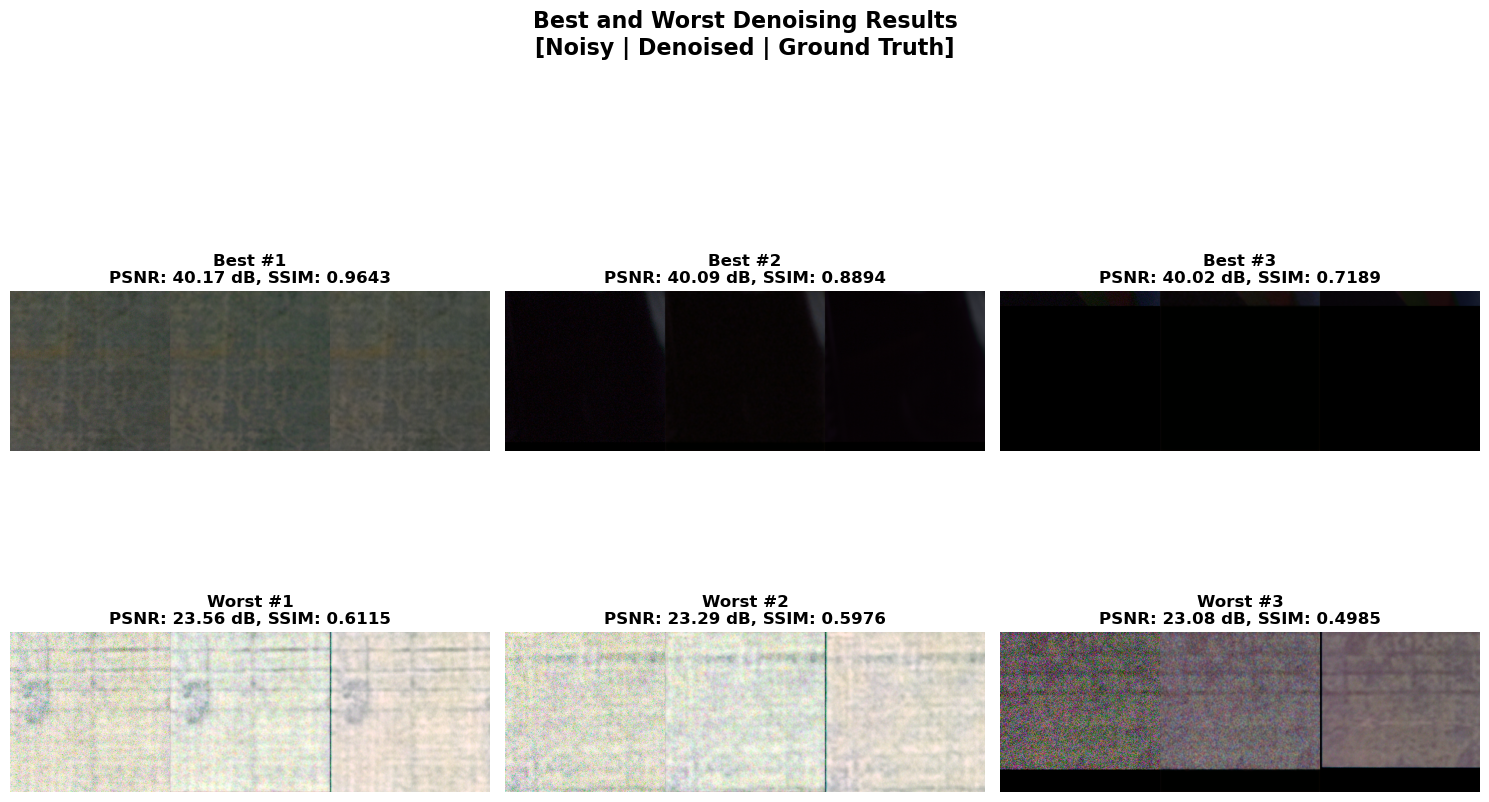

In [9]:
show_best_worst_results(
    results=test_pipeline.test_results,
    test_loader=test_loader,
    model=test_pipeline.model,
    device=device
)

Statistical analysis

In [10]:
print_test_statistics(results=test_pipeline.test_results)


STATISTICAL ANALYSIS

PSNR Statistics:
    Mean: 33.95 dB
    Std: 3.33 dB
    Min: 23.08 dB
    Max: 40.17 dB
    Median: 34.61 dB

SSIM Statistics:
    Mean: 0.8538
    Std: 0.1030
    Min: 0.4480
    Max: 0.9741
    Median: 0.8893


Percentile analysis

In [11]:
print_percentile_analysis(test_results=test_pipeline.test_results)

PERCENTILE ANALYSIS
25th percentile: 31.90 dB
50th percentile: 34.61 dB  (median)
75th percentile: 36.54 dB
90th percentile: 37.66 dB
95th percentile: 38.16 dB

Interquartile range (IQR): 4.64 dB
High variability in performance across images


Compare with baseline (noisy images)

In [12]:
history_path = Path(checkpoint_dir) / "training_history.json"
history = None
if history_path.exists():
    history = load_training_history(load_path=history_path)
    print_best_results(history=history, verbose=False)



Loaded training history from ..\runs\20260222-130917\training_history.json
BEST VALIDATION RESULTS
Best epoch: 20 / 26
Best val PSNR: 32.53 dB
Best val SSIM: 0.8531


In [13]:
compare_with_validation(test_results=test_pipeline.test_results, history=history)

GENERALISATION ANALYSIS

PSNR:
    Best val: 32.53 dB
    Test: 33.95 dB
    Gap: -1.42 dB

SSIM:
    Best val: 0.8673
    Test: 0.8538
    Gap: +0.0135

Assessment:
    Fair generalisation (gap < 2.0 dB)


Error analysis

In [14]:
# Show cases where model struggles
# Identify patterns in failure cases
analyse_failure_cases(test_results=test_pipeline.test_results, threshold_psnr=28.0)

FAILURE CASE ANALYSIS (PSNR < 28.0 dB)

 Failed images: 53 / 846 (6.3%)

Failure statistics:
    Mean PSNR: 26.57 dB
    Worst PSNR: 23.08 dB
    Std: 1.19 dB

Worst 5 cases:
    1. Image 286: PSNR=23.08 dB, SSIM=0.4985
    2. Image 633: PSNR=23.29 dB, SSIM=0.5976
    3. Image 291: PSNR=23.56 dB, SSIM=0.6115
    4. Image 611: PSNR=24.18 dB, SSIM=0.5781
    5. Image 233: PSNR=24.39 dB, SSIM=0.4629


Generate comprehensive report

In [15]:
report = create_evaluation_report(
    test_results=test_pipeline.test_results,
    history=history,
    checkpoint_dir=checkpoint_dir
)

In [16]:
# Print report
print(report)

# Save report to file
report_path = Path(checkpoint_dir) / "evaluation_report.txt"
with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print(f"\nReport saved to {report_path}")

EVALUATION REPORT

Checkpoint: ../runs/20260222-130917

Test Set:
     Images: 846

Overall Performance:
     Average PSNR: 33.95 dB
     Average SSIM: 0.8538

PSNR Statistics:
  Mean:   33.95 dB
  Median: 34.61 dB
  Std:    3.33 dB
  Range:  [23.08, 40.17] dB

SSIM Statistics:
  Mean:   0.8538
  Median: 0.8893
  Std:    0.1030
  Range:  [0.4480, 0.9741]

Percentiles (PSNR):
  25th: 31.90 dB
  50th: 34.61 dB
  75th: 36.54 dB
  90th: 37.66 dB
  95th: 38.16 dB

Generalization:
  Best val PSNR: 32.53 dB
  Test PSNR:     33.95 dB
  Gap:           -1.42 dB
  Assessment: Check generalization

Best result:
  Image 297: PSNR=40.17 dB, SSIM=0.9643

Worst result:
  Image 286: PSNR=23.08 dB, SSIM=0.4985


Report saved to ..\runs\20260222-130917\evaluation_report.txt


Complete evaluation summary

In [17]:
print_evaluation_summary(test_results=test_pipeline.test_results, history=history)


EVALUATION SUMMARY

 Test Results:
    Images tested: 846
    Avg PSNR: 33.95 dB
    Avg SSIM: 0.8538

 PSNR Distribution:
    Range: [23.08, 40.17] dB
    Std: 3.33 dB

 Val/Test Gap:
    Best val PSNR: 32.53 dB
    Gap: -1.42 dB
    Check generalisation
